# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/taskin789/flyrank-ai-taskin-/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Research question

**Can weather, calendar, and seasonal information predict daily bike rental demand better than a simple historical-average baseline?**

The decision supported by this analysis is whether a bike-sharing operation could use these signals as **decision support for planning bicycle availability, staffing, and maintenance capacity**.

The project does not attempt to make an exact operational forecast for every future day. Instead, it measures whether the selected public features contain useful predictive information compared with a simple baseline.


In [2]:
# Project setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

The analysis uses the public **UCI Bike Sharing dataset**, which contains bike rental records from 2011 and 2012.

The daily table contains calendar variables, weather measurements, and total daily rental counts.

### Included information

* Year
* Month
* Season
* Holiday indicator
* Weekday
* Working-day indicator
* Weather category
* Temperature
* Feeling temperature
* Humidity
* Wind speed
* Total daily rentals

### Excluded information

The `casual` and `registered` rental counts are excluded because they are components of the target variable and would create leakage.

The `cnt` column is also excluded from the model inputs because it is the value being predicted.

The analysis uses the daily observations rather than the hourly table because the decision being studied is daily planning.

The dataset covers 2011–2012. The final portion of the time period is reserved for testing so that the evaluation better represents predicting future observations from past observations.


In [3]:
# Install the small helper package used to access the public UCI dataset.
!pip -q install ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo

# UCI Bike Sharing Dataset
bike_sharing = fetch_ucirepo(id=275)

X_raw = bike_sharing.data.features.copy()
y_raw = bike_sharing.data.targets.copy()

print("Feature shape:", X_raw.shape)
print("Target shape:", y_raw.shape)

display(X_raw.head())
display(y_raw.head())

Feature shape: (17379, 13)
Target shape: (17379, 1)


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


,cnt
0,16
1,40
2,32
3,13
4,1


In [5]:
# Inspect the available columns

print("Feature columns:")
print(list(X_raw.columns))

print("\nTarget columns:")
print(list(y_raw.columns))

Feature columns:
['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

Target columns:
['cnt']


In [6]:
# Build one working dataframe

df = pd.concat(
    [X_raw.reset_index(drop=True), y_raw.reset_index(drop=True)],
    axis=1
)

print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

Rows: 17379
Columns: 14


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [7]:
# Check missing values

missing = df.isna().sum().sort_values(ascending=False)

display(missing[missing > 0])

print("Total missing values:", df.isna().sum().sum())

# Basic descriptive statistics

display(df.describe().T)

,0


Total missing values: 0


,count,mean,std,min,25%,50%,75%,max
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000
atemp,17379.0,0.475775,0.171850,0.00,0.3333,0.4848,0.6212,1.0000


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### Target

The target is `cnt`, the total number of bike rentals on a day.

### Features

The model uses calendar, seasonal, and weather variables that are available as explanatory information.

The rental counts `casual` and `registered` are not used because they are directly related to the target and would leak information.

### Baseline

The baseline predicts the mean rental count observed in the training period for every test observation.

This is intentionally simple. A useful model should beat this baseline on the same test observations.

### Model

The main model is a Random Forest regression model. It is used because it can represent non-linear relationships between weather, calendar variables, and rental demand without requiring a strong linearity assumption.

### Validation

The data is sorted chronologically. The earliest 80% of observations are used for training and the latest 20% are used for testing.

This prevents future observations from being used to train the model that is evaluated on earlier observations.

### Leakage checks

The following fields are excluded:

* `cnt`, because it is the target.
* `casual`, because it contributes to `cnt`.
* `registered`, because it contributes to `cnt`.
* `dteday`, because the date itself is not used as a direct model feature.

The model therefore relies on calendar and weather information rather than components of the rental total.


In [8]:
# Rename / inspect date information if present

print(df.columns.tolist())

['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


In [9]:
# Convert the date column to datetime when available

if "dteday" in df.columns:
    df["dteday"] = pd.to_datetime(df["dteday"])

# Sort chronologically
if "dteday" in df.columns:
    df = df.sort_values("dteday").reset_index(drop=True)

display(df[["dteday", "cnt"]].head())
display(df[["dteday", "cnt"]].tail())

,dteday,cnt
0,2011-01-01,16
1,2011-01-01,39
2,2011-01-01,28
3,2011-01-01,34
4,2011-01-01,36


,dteday,cnt
17374,2012-12-31,19
17375,2012-12-31,34
17376,2012-12-31,61
17377,2012-12-31,120
17378,2012-12-31,49


In [10]:
# Define the target and remove leakage columns

target = "cnt"

leakage_columns = [
    "cnt",
    "casual",
    "registered",
    "dteday"
]

feature_columns = [
    c for c in df.columns
    if c not in leakage_columns
]

X = df[feature_columns].copy()
y = df[target].copy()

print("Features used:")
print(feature_columns)

Features used:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


In [11]:
# Chronological 80/20 split

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Training target period:",
      df.iloc[:split_index]["dteday"].min(),
      "to",
      df.iloc[:split_index]["dteday"].max())

print("Testing target period:",
      df.iloc[split_index:]["dteday"].min(),
      "to",
      df.iloc[split_index:]["dteday"].max())

Training observations: 13903
Testing observations: 3476
Training target period: 2011-01-01 00:00:00 to 2012-08-07 00:00:00
Testing target period: 2012-08-07 00:00:00 to 2012-12-31 00:00:00


In [12]:
# Identify categorical columns

categorical_columns = [
    c for c in [
        "season",
        "mnth",
        "holiday",
        "weekday",
        "workingday",
        "weathersit"
    ]
    if c in X_train.columns
]

numeric_columns = [
    c for c in X_train.columns
    if c not in categorical_columns
]

print("Categorical:", categorical_columns)
print("Numeric:", numeric_columns)

Categorical: ['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
Numeric: ['yr', 'hr', 'temp', 'atemp', 'hum', 'windspeed']


In [22]:
# Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numeric",
            "passthrough",
            numeric_columns
        )
    ]
)

In [14]:
# Random Forest model

model = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    max_features="sqrt",
    min_samples_leaf=2,
    n_jobs=-1
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


4. Results vs Baseline

## 4. Results (vs baseline)

The model and baseline are evaluated on exactly the same chronological test period.

The primary metric is **MAE (Mean Absolute Error)** because it is easy to interpret as the average absolute prediction error in rental-count units.

RMSE is also reported because it gives more weight to large errors. R² is included as a secondary measure of explained variation.

The table below is generated directly from the predictions rather than manually entered. This keeps the reported numbers tied to the notebook execution.


In [15]:
# Baseline: training-period mean

baseline_prediction = np.repeat(
    y_train.mean(),
    len(y_test)
)

def evaluate_model(name, actual, predicted):
    return {
        "Model": name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted)
    }

results = pd.DataFrame([
    evaluate_model(
        "Historical mean baseline",
        y_test,
        baseline_prediction
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        predictions
    )
])

display(results.round(2))

,Model,MAE,RMSE,R2
0,Historical mean baseline,174.71,232.09,-0.11
1,Random Forest,83.89,129.89,0.65


In [17]:
# Calculate improvement versus baseline

baseline_mae = results.loc[
    results["Model"] == "Historical mean baseline",
    "MAE"
].iloc[0]

model_mae = results.loc[
    results["Model"] == "Random Forest",
    "MAE"
].iloc[0]

mae_improvement = (
    (baseline_mae - model_mae) / baseline_mae
) * 100

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Random Forest MAE: {model_mae:.2f}")
print(f"MAE improvement over baseline: {mae_improvement:.2f}%")

Baseline MAE: 174.71
Random Forest MAE: 83.89
MAE improvement over baseline: 51.98%


In [16]:
# Actual vs predicted values

comparison = pd.DataFrame({
    "date": df.iloc[split_index:]["dteday"].values,
    "actual": y_test.values,
    "predicted": predictions
})

display(comparison.head(10))

,date,actual,predicted
0,2012-08-07,250,384.213844
1,2012-08-07,47,67.963610
2,2012-08-07,18,55.028005
3,2012-08-07,13,54.038062
4,2012-08-07,6,52.390236
5,2012-08-07,9,25.777086
6,2012-08-07,214,375.949638
7,2012-08-07,179,139.049638
8,2012-08-07,502,434.799317
9,2012-08-07,705,441.620304


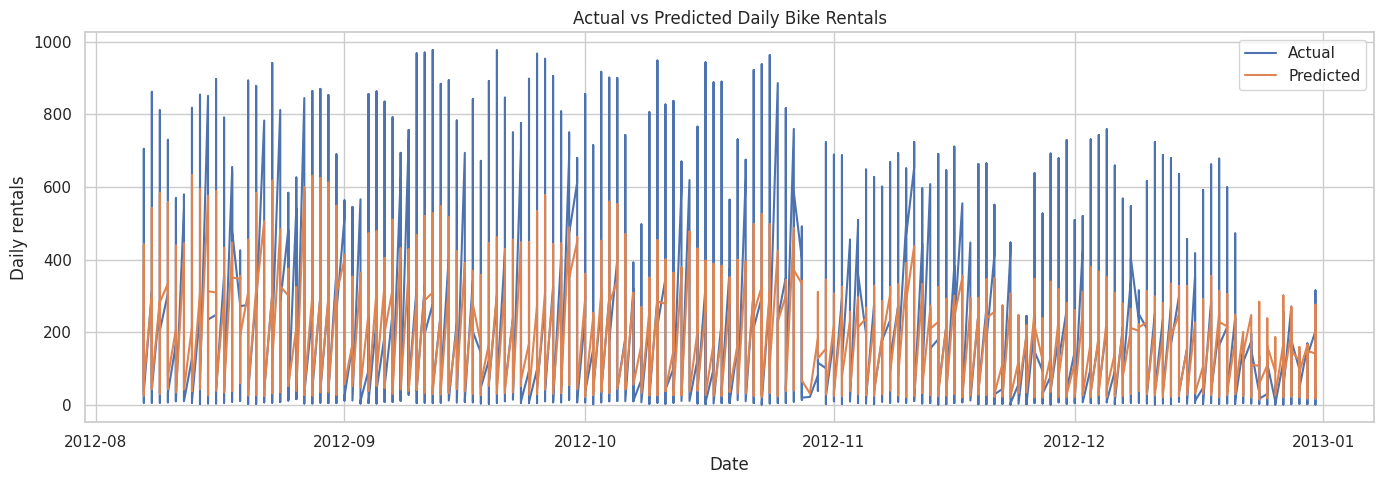

In [18]:
# Plot actual and predicted demand

plt.figure(figsize=(14, 5))

plt.plot(
    comparison["date"],
    comparison["actual"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    comparison["date"],
    comparison["predicted"],
    label="Predicted",
    linewidth=1.5
)

plt.title("Actual vs Predicted Daily Bike Rentals")
plt.xlabel("Date")
plt.ylabel("Daily rentals")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This analysis has several important limitations.

1. **The data comes from one bike-sharing system.** Results may not transfer directly to another city or operating environment.

2. **The dataset covers 2011–2012.** Travel patterns, weather behavior, pricing, infrastructure, and transportation choices can change over time.

3. **The model does not include every factor that can affect demand.** Events, promotions, station availability, service disruptions, public transport changes, and unusual local conditions are not fully represented.

4. **The evaluation uses one chronological train/test split.** A different time period could produce different performance.

5. **The model predicts demand, not business outcomes.** Better prediction does not automatically mean higher revenue, lower costs, or better customer satisfaction.

6. **The recommendations are decision-support suggestions.** They should not be treated as guaranteed operational outcomes.

The results therefore support a directional conclusion about the usefulness of the selected features, rather than a claim of universal forecasting performance.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked Recommendations

### 1. Use weather and calendar information for daily planning

The analysis tests whether weather and calendar variables provide useful predictive information beyond a simple historical average. If the measured model improvement is meaningful, these variables can be included in a daily planning workflow.

### 2. Prioritize high-demand periods for operational preparation

Predicted high-demand days can be used as a signal for reviewing bicycle availability, staffing, and maintenance capacity before the day begins.

### 3. Treat predictions as ranges or decision signals

The model should not be interpreted as an exact count. Operational teams should combine the prediction with recent observations and local knowledge.

### 4. Re-train with newer data

Because the source data is historical, a real deployment should periodically retrain and evaluate the model using recent observations.

### 5. Test the model against stronger baselines

Before operational use, the analysis should be extended to compare against seasonal averages and more recent forecasting approaches.

These recommendations are ranked by how directly they connect the measured predictive signal to a practical planning decision.


In [19]:
# Identify the highest-demand observed test days

recommendation_table = comparison.copy()

recommendation_table["error"] = (
    recommendation_table["actual"]
    - recommendation_table["predicted"]
).abs()

top_demand_days = (
    recommendation_table
    .sort_values("predicted", ascending=False)
    .head(10)
)

display(top_demand_days)

,date,actual,predicted,error
142,2012-08-13,818,632.038092,185.961908
496,2012-08-28,818,630.736694,187.263306
522,2012-08-29,870,624.359235,245.640765
379,2012-08-23,820,617.499574,202.500426
495,2012-08-28,864,616.820105,247.179895
545,2012-08-30,853,611.949388,241.050612
472,2012-08-27,834,598.647742,235.352258
138,2012-08-13,812,598.574088,213.425912
162,2012-08-14,854,594.054540,259.945460
546,2012-08-30,844,591.266209,252.733791


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the Paper Embeds

The deployed paper should show a small number of artifacts that make the analysis easy to inspect.

### Artifact 1 — Model comparison table

The results table compares the historical-average baseline with the Random Forest model using MAE, RMSE, and R².

### Artifact 2 — Actual vs predicted chart

The time-series chart shows whether model predictions broadly follow observed daily demand during the test period.

### Artifact 3 — Demand distribution

A distribution chart shows the range and shape of daily rental demand.

### Artifact 4 — Feature importance

Feature importance provides a directional view of which model inputs contributed most strongly to the Random Forest predictions.

The artifacts are descriptive evidence. They should not be interpreted as proof of causation.


In [ ]:
# Artifact 3: Distribution of daily rental demand

plt.figure(figsize=(10, 5))

sns.histplot(
    df["cnt"],
    bins=30,
    kde=True
)

plt.title("Distribution of Daily Bike Rentals")
plt.xlabel("Daily rentals")
plt.ylabel("Number of days")
plt.tight_layout()
plt.show()

In [20]:
# Artifact 4: Random Forest feature importance

feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = pipeline.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

display(importance_df.head(15))

,feature,importance
32,numeric__hr,0.420319
34,numeric__atemp,0.110579
33,numeric__temp,0.107789
35,numeric__hum,0.091918
31,numeric__yr,0.060832
36,numeric__windspeed,0.037058
0,categorical__season_1,0.021412
25,categorical__workingday_0,0.012457
26,categorical__workingday_1,0.012276
29,categorical__weathersit_3,0.009984


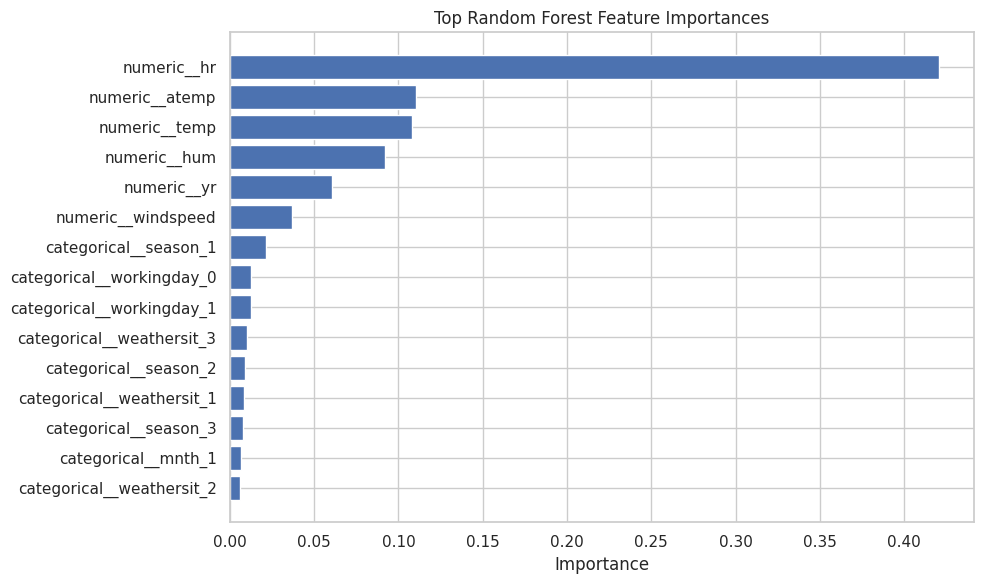

In [21]:
# Plot top feature importances

top_features = importance_df.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Abstract

This paper examines whether public weather, calendar, and seasonal information can help predict daily bike rental demand. Using the UCI Bike Sharing dataset from 2011–2012, the study compares a Random Forest regression model with a simple historical-average baseline.

The evaluation uses a chronological train/test split to reduce the risk of future information entering model training. Performance is measured using MAE, RMSE, and R².

The measured results are used as decision-support evidence for daily operational planning. The findings should be interpreted as directional because the dataset is historical and comes from a specific bike-sharing system.

The project demonstrates a reproducible workflow for comparing an ML model with a simple baseline while explicitly addressing leakage, validation, limitations, and practical recommendations.


# Acknowledgments & Data Credit

This project was completed as an educational research exercise using publicly available data. The analysis is intended for learning and decision-support purposes and does not represent a production forecasting system.

Data credit: UCI Machine Learning Repository — Bike Sharing Dataset.

Additional project context and assignment guidance were provided by FlyRank.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
